# STAGE 4 — SPENDABLE ENGINE EXPLORATION & HISTORICAL BACKTESTING

This notebook explores and evaluates the core financial intelligence engine of **Spendable**.

### Key Objectives:
1. **Core Product Proposition**: Transform raw balance into safe spending capacity: *"Your balance tells you how much money you have. Spendable tells you how much you can realistically afford to spend."*
2. **Candidate Methodologies**:
   - **Candidate A (Recommended)**: Non-Double-Counting Protected Requirement ($\max(C_{\text{out}}, B_0 - B_{\min}) + R_{\text{safe}}$)
   - **Candidate B**: Forecast-Aware Trajectory Buffer ($B_{\min} - R_{\text{safe}}$)
   - **Candidate C**: Commitment-Aware Direct Cash ($B_0 - C_{\text{out}} - R_{\text{safe}}$)
3. **Adaptive Safety Reserve**: Behavior-driven safety buffer scaling with spending volatility, income irregularity, and commitment ratio.
4. **Historical Backtesting**: Empirical evaluation across **10,981 historical snapshots** (TRAIN / VALIDATION / TEST splits) against future ground truth minimum balance outcomes.
5. **Categorical Liquidity States**: Classification into `HEALTHY`, `WATCH`, and `PRESSURED`.
6. **Machine-Readable Explanation Factors**: Structured output payloads for downstream Gemini NLP integration.


In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Setup sys.path to backend
sys.path.insert(0, str(Path.cwd().parent / "backend"))

from app.engine.schema import SpendableOutput, LiquidityState, FactorType, FactorImpact
from app.engine.safety import AdaptiveSafetyReserveCalculator
from app.engine.calculator import SpendableCalculator
from app.engine.backtest import SpendableBacktester
from app.recurring.schema import (
    DetectedCommitment, DetectionEvidence, DetectionStatus, RecurrenceIntervalType
)
from app.forecasting.models import CashFlowForecastModel

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.sans-serif"] = "Segoe UI"


## 1. Candidate Methodology Formulations

We test three candidate formulations to protect liquidity without double-counting recurring commitments already present in forecasted balance drawdowns:

- **Candidate A (Recommended - Non-Double-Counting Protected Requirement)**:
  $$\text{Protected} = \max(C_{\text{commitments}}, B_0 - B_{\min\_30d}) + R_{\text{safe}}$$
  $$\text{Spendable} = \max(0, B_0 - \text{Protected})$$

- **Candidate B (Forecast-Aware Trajectory Buffer)**:
  $$\text{Protected} = (B_0 - B_{\min\_30d}) + R_{\text{safe}}$$
  $$\text{Spendable} = \max(0, B_{\min\_30d} - R_{\text{safe}})$$

- **Candidate C (Commitment-Aware Direct Cash Buffer)**:
  $$\text{Protected} = C_{\text{commitments}} + R_{\text{safe}}$$
  $$\text{Spendable} = \max(0, B_0 - C_{\text{commitments}} - R_{\text{safe}})$$


In [2]:
# Instantiate calculator and test candidate formulations on a baseline sample
calculator = SpendableCalculator()

sample_balance = 50000.0
sample_features = {
    "current_balance": 50000.0,
    "total_outflow_30d": 30000.0,
    "spending_volatility_30d": 1200.0,
    "total_inflow_30d": 40000.0,
    "inflow_volatility_30d": 500.0,
}

sample_commitments = [
    DetectedCommitment(
        commitment_id="comm_rent_10000",
        user_id="demo_user",
        category="RENT",
        activity_type="RENT",
        direction="OUTFLOW",
        is_commitment=True,
        expected_amount=10000.0,
        recurrence_interval=RecurrenceIntervalType.MONTHLY,
        median_interval_days=30.0,
        next_expected_date="2026-04-01",
        amount_variability=0.0,
        occurrence_count=4,
        confidence_score=0.95,
        commitment_likelihood=0.90,
        detection_status=DetectionStatus.STRONG,
        evidence=DetectionEvidence(
            occurrences=4, median_interval_days=30.0, mean_interval_days=30.0,
            std_interval_days=0.5, interval_cv=0.02, mean_amount=10000.0,
            median_amount=10000.0, std_amount=0.0, amount_cv=0.0, recency_days=5.0,
            active_duration_days=90.0, interval_consistency_score=0.95,
            amount_consistency_score=1.0, recency_score=0.9, count_score=0.8,
            counterparty_score=0.8, commitment_likelihood_score=0.9
        )
    )
]

candidates = calculator.evaluate_candidates(
    current_balance=50000.0,
    upcoming_commitments=10000.0,
    forecasted_min_balance=35000.0,
    safety_reserve=5000.0,
)

df_cand = pd.DataFrame([res.model_dump() for res in candidates.values()])
print("--- Candidate Spendable Formulations Comparison ---")
print(df_cand[["candidate_name", "spendable_amount", "protected_amount", "safety_reserve", "liquidity_state"]])


--- Candidate Spendable Formulations Comparison ---
  candidate_name  spendable_amount  protected_amount  safety_reserve  \
0    CANDIDATE_A           30000.0           20000.0          5000.0   
1    CANDIDATE_B           30000.0           20000.0          5000.0   
2    CANDIDATE_C           35000.0           15000.0          5000.0   

          liquidity_state  
0  LiquidityState.HEALTHY  
1  LiquidityState.HEALTHY  
2  LiquidityState.HEALTHY  


## 2. Adaptive Safety Reserve Behavior Analysis

The `AdaptiveSafetyReserveCalculator` dynamically scales safety buffers based on spending volatility, income irregularity, and commitment ratio.


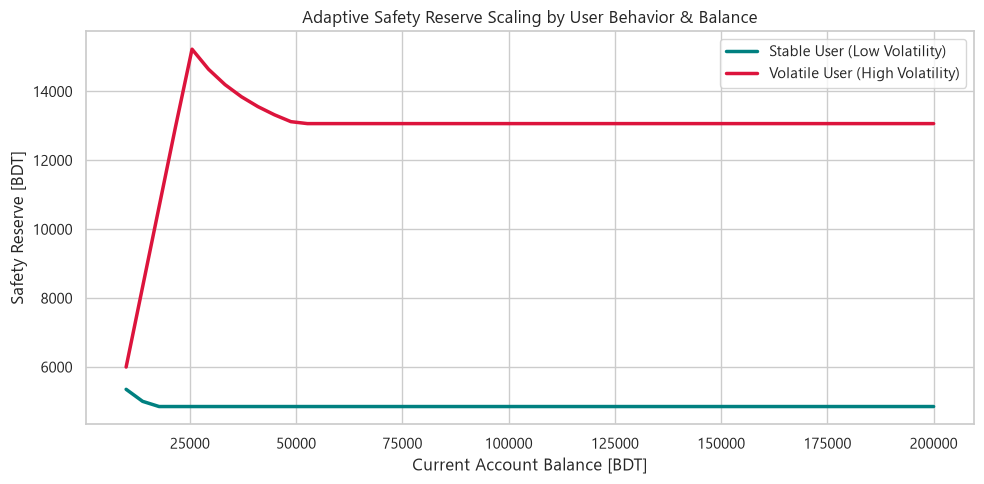

In [3]:
safety_calc = AdaptiveSafetyReserveCalculator(min_reserve_bdt=3000.0)

balances = np.linspace(10000, 200000, 50)
reserves_stable = []
reserves_volatile = []

for b in balances:
    res_stable = safety_calc.calculate_reserve(
        current_balance=b, outflow_sum_30d=20000.0, outflow_std_30d=200.0,
        income_sum_30d=30000.0, income_std_30d=100.0, upcoming_commitments=5000.0
    )
    res_vol = safety_calc.calculate_reserve(
        current_balance=b, outflow_sum_30d=20000.0, outflow_std_30d=3500.0,
        income_sum_30d=30000.0, income_std_30d=6000.0, upcoming_commitments=15000.0
    )
    reserves_stable.append(res_stable.total_reserve)
    reserves_volatile.append(res_vol.total_reserve)

plt.figure(figsize=(10, 5))
plt.plot(balances, reserves_stable, label="Stable User (Low Volatility)", color="teal", linewidth=2.5)
plt.plot(balances, reserves_volatile, label="Volatile User (High Volatility)", color="crimson", linewidth=2.5)
plt.title("Adaptive Safety Reserve Scaling by User Behavior & Balance")
plt.xlabel("Current Account Balance [BDT]")
plt.ylabel("Safety Reserve [BDT]")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Historical Backtesting Across Dataset Splits

We load snapshot datasets (`features_train.csv`, `features_validation.csv`, `features_test.csv`) and evaluate Candidate A, B, and C against actual future 30-day minimum balance outcomes.


In [4]:
data_dir = Path.cwd().parent / "data" / "features"
train_df = pd.read_csv(data_dir / "features_train.csv")
val_df = pd.read_csv(data_dir / "features_validation.csv")
test_df = pd.read_csv(data_dir / "features_test.csv")

print(f"Loaded train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)} snapshots")

# Fit forecasting model on train
model = CashFlowForecastModel()
model.fit(train_df)
forecast_models = {"model": model}

# Backtest on test set
backtester = SpendableBacktester()
report_test = backtester.backtest_split(
    df_split=test_df, split_name="TEST", forecast_models=forecast_models
)

print("\n--- TEST SPLIT BACKTEST REPORT SUMMARY ---")
for cand_key, metrics in report_test.candidate_metrics.items():
    print(f"[{metrics.candidate_name}]")
    print(f"  Mean Spendable: ৳{metrics.mean_spendable_bdt:,.2f}")
    print(f"  Median Spendable: ৳{metrics.median_spendable_bdt:,.2f}")
    print(f"  Safety Breach Rate: {metrics.safety_breach_rate:.2f}%")
    print(f"  Zero Spendable Rate: {metrics.zero_spendable_rate:.2f}%")
    print(f"  Avg Unallocated Buffer: ৳{metrics.avg_unallocated_buffer_bdt:,.2f}\n")


Loaded train: 7685 | val: 1647 | test: 1649 snapshots

--- TEST SPLIT BACKTEST REPORT SUMMARY ---
[CANDIDATE_A (Non-Double-Counting Protected)]
  Mean Spendable: ৳325,967.26
  Median Spendable: ৳228,003.57
  Safety Breach Rate: 51.18%
  Zero Spendable Rate: 6.61%
  Avg Unallocated Buffer: ৳8,047.11

[CANDIDATE_B (Forecast-Aware Trajectory Buffer)]
  Mean Spendable: ৳328,019.35
  Median Spendable: ৳231,664.78
  Safety Breach Rate: 51.55%
  Zero Spendable Rate: 6.37%
  Avg Unallocated Buffer: ৳7,165.55

[CANDIDATE_C (Commitment-Aware Direct Cash)]
  Mean Spendable: ৳344,721.66
  Median Spendable: ৳242,524.46
  Safety Breach Rate: 89.14%
  Zero Spendable Rate: 2.67%
  Avg Unallocated Buffer: ৳4,246.87



## 4. Representative Persona Deep Dives (6 User Archetypes)

We analyze Spendable engine recommendations across 6 key user profiles:
1. **STABLE**: Regular income, low volatility, moderate spending
2. **TIGHT_LIQUIDITY**: High spending relative to balance
3. **IRREGULAR_INCOME**: Freelance / high income variability
4. **COMMITMENT_HEAVY**: High recurring bills
5. **FINANCIAL_PRESSURE**: Low balance, negative net cash flow
6. **SPENDING_DRIFT**: Discretionary spending acceleration


In [5]:
# Sample snapshots for personas
personas = test_df["persona"].unique()
sample_rows = []

for p in personas:
    p_subset = test_df[test_df["persona"] == p]
    if len(p_subset) > 0:
        row = p_subset.iloc[0].to_dict()
        out = calculator.calculate(
            user_id=str(row.get("account_id", "USER")),
            snapshot_time=str(row.get("snapshot_time", "2026-03-01")),
            current_balance=float(row.get("current_balance", 0.0)),
            features=row,
            commitments=[],
            forecast=model.predict_snapshot(row),
            candidate_methodology="CANDIDATE_A"
        )
        sample_rows.append({
            "Persona": p,
            "Balance [BDT]": out.current_balance,
            "Expected Inflow": out.expected_inflow,
            "Upcoming Commitments": out.upcoming_commitments,
            "Forecasted Min Bal": out.forecasted_minimum_balance,
            "Safety Reserve": out.safety_reserve,
            "Spendable Amount": out.spendable_amount,
            "Liquidity State": out.liquidity_state.value
        })

df_persona_summary = pd.DataFrame(sample_rows)
print("--- Persona Execution Breakdown ---")
print(df_persona_summary.to_string(index=False))


--- Persona Execution Breakdown ---
           Persona  Balance [BDT]  Expected Inflow  Upcoming Commitments  Forecasted Min Bal  Safety Reserve  Spendable Amount Liquidity State
   TIGHT_LIQUIDITY       59835.05         79159.12                   0.0            34284.50        11731.74          22552.76         HEALTHY
FINANCIAL_PRESSURE       69862.50         53967.60                   0.0            81809.58        10711.68          59150.82         HEALTHY
    SPENDING_DRIFT       89027.18         63542.62                   0.0            98728.53        13053.63          75973.55         HEALTHY
            STABLE      219411.29        128271.78                   0.0           162838.37        23486.18         139352.19         HEALTHY
  COMMITMENT_HEAVY       84712.76         71880.48                   0.0            94812.07        22321.16          62391.60         HEALTHY
  IRREGULAR_INCOME       66416.00         67166.00                   0.0            42275.95        20483.

## 5. Machine-Readable Explanation Factor Inspection

Spendable produces structured, machine-readable factor objects designed to be passed to Gemini for natural language synthesis.


In [6]:
# Inspect factor output payload for a sample user
sample_row = test_df.iloc[0].to_dict()
sample_out = calculator.calculate(
    user_id=str(sample_row.get("account_id", "USER")),
    snapshot_time=str(sample_row.get("snapshot_time", "2026-03-01")),
    current_balance=float(sample_row.get("current_balance", 0.0)),
    features=sample_row,
    commitments=sample_commitments,
    forecast=model.predict_snapshot(sample_row),
    candidate_methodology="CANDIDATE_A"
)

print(f"User ID: {sample_out.user_id}")
print(f"Current Balance: ৳{sample_out.current_balance:,.2f}")
print(f"Spendable Amount: ৳{sample_out.spendable_amount:,.2f}")
print(f"Liquidity State: {sample_out.liquidity_state}")
print("\nGenerated Factors for Downstream Gemini Explanation:")
for f in sample_out.factors:
    print(f" - [{f.type.value}] ({f.impact.value}) {f.description}")


User ID: ACC-0497
Current Balance: ৳59,835.05
Spendable Amount: ৳22,552.76
Liquidity State: LiquidityState.HEALTHY

Generated Factors for Downstream Gemini Explanation:
 - [UPCOMING_COMMITMENT] (NEGATIVE) ৳10,000.00 reserved for detected recurring bills and commitments over 30 days.
 - [EXPECTED_INFLOW] (POSITIVE) ৳79,159.12 projected incoming cash flow over next 30 days.
 - [FORECAST_MINIMUM] (POSITIVE) Forecasted minimum account balance remains safe at ৳34,284.50.
 - [SAFETY_BUFFER] (NEGATIVE) ৳11,731.74 allocated to adaptive safety reserve buffer for unexpected expenses.
